# Visualisation - Pipeline de severite RSWA

Ce notebook lit les sorties de `run_pipeline.py` sous `results/` et produit
les visualisations correspondantes. Il ne recalcule rien : toutes les
figures sont construites a partir des CSV deja sauvegardes par les etapes
1-5 du pipeline.

**Pre-requis** : avoir lance `run_pipeline.py --steps 1 2 3 4 5` (ou au
moins les etapes dont vous voulez voir les resultats) avant d'executer ce
notebook.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# Localisation de results/ : ce notebook est cense vivre dans notebooks/,
# results/ est cote a cote (meme convention que results_io.py). On essaie
# plusieurs emplacements plausibles pour rester robuste au dossier de
# lancement de Jupyter.
CANDIDATES = [Path("../results"), Path("results"), Path("./results")]
RESULTS_ROOT = next((p for p in CANDIDATES if p.exists()), None)
if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Dossier results/ introuvable. Lancez ce notebook depuis notebooks/ "
        "(results/ doit etre au meme niveau que notebooks/ et scripts/), ou "
        "ajustez RESULTS_ROOT manuellement ci-dessus."
    )
print("RESULTS_ROOT =", RESULTS_ROOT.resolve())

# Palette coherente avec les scripts 06-09 de l'ancien pipeline
PALETTE = {"AI": "#C9D175", "Narco": "#F15854", "Syn": "#44AA99", "iRBD": "#BEBEBE"}
GROUP_ORDER = ["AI", "Narco", "Syn", "iRBD"]


RESULTS_ROOT = C:\dev\Cerco_studies\results


## 1. Cohorte : chargement et vue d'ensemble

76 patients charges depuis ..\results\cohort\cohort_metrics_real.csv


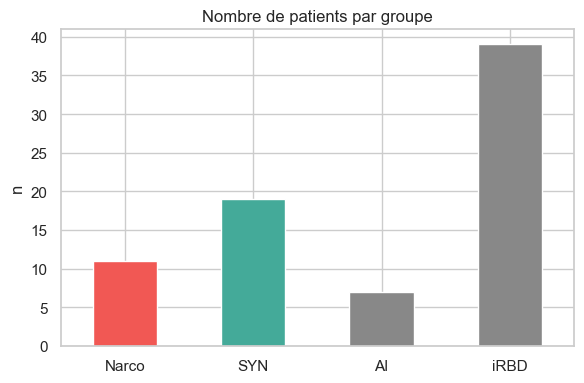

,subject_id,diagnosis,AI_atonia_index,AI_atonia_index_category,episode_count,pct_epochs_artifact
0,AE129,Narco,0.748721,abnormal,477,3.171355
1,AN166,AI,0.905976,normal,90,1.515152
2,BA152,SYN,0.696696,abnormal,115,0.804598
3,BA171,SYN,0.822412,ambiguous,96,0.888889
4,BB114,SYN,0.432555,abnormal,191,0.289855
5,BDRE44,Narco,0.884183,ambiguous,233,3.125618
6,BF181,SYN,0.381609,abnormal,216,0.000000
7,BJ138,iRBD,0.846594,ambiguous,28,1.505376
8,BO60,SYN,0.379349,abnormal,88,0.751174
9,CA169,iRBD,0.621459,abnormal,345,0.875421


In [ ]:
cohort_path = RESULTS_ROOT / "cohort" / "cohort_metrics_real.csv"
df = pd.read_csv(cohort_path)
print(f"{len(df)} patients charges depuis {cohort_path}")

group_order_present = [g for g in GROUP_ORDER if g in df["diagnosis"].unique()]
other_groups = [g for g in df["diagnosis"].unique() if g not in group_order_present]
display_order = group_order_present + sorted(other_groups)

df["diagnosis"].value_counts().reindex(display_order).plot(
    kind="bar", color=[PALETTE.get(g, "#888888") for g in display_order], figsize=(6, 4)
)
plt.title("Nombre de patients par groupe")
plt.ylabel("n")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df[["subject_id", "diagnosis", "AI_atonia_index", "AI_atonia_index_category",
    "episode_count", "pct_epochs_artifact"]].head(10)


## 2. Atonia Index par groupe

Rappel des seuils (Ferri 2010) : **abnormal** (AI<0.8), **ambiguous**
(0.8-0.9), **normal** (>=0.9).


C:\Users\U1108091\AppData\Local\Temp\ipykernel_30592\1097319471.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="diagnosis", y="AI_atonia_index", order=display_order,


ValueError: The palette dictionary is missing keys: {'AI', 'iRBD'}

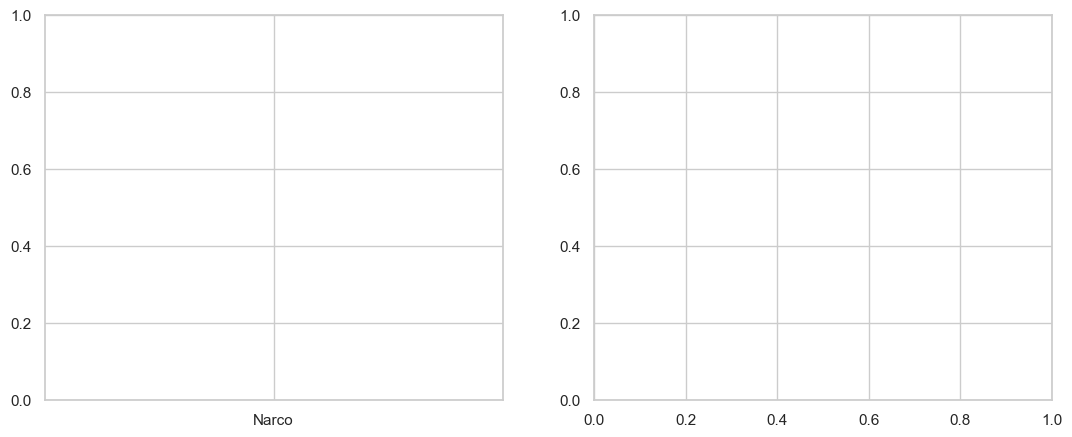

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="diagnosis", y="AI_atonia_index", order=display_order,
            palette=PALETTE, showfliers=False, ax=axes[0])
sns.stripplot(data=df, x="diagnosis", y="AI_atonia_index", order=display_order,
              color="black", alpha=0.5, size=4, jitter=True, ax=axes[0])
axes[0].axhline(0.8, color="red", linestyle="--", linewidth=1, label="seuil abnormal (0.8)")
axes[0].axhline(0.9, color="orange", linestyle="--", linewidth=1, label="seuil ambiguous (0.9)")
axes[0].set_title("Atonia Index par groupe")
axes[0].legend(fontsize=8)

cat_counts = (df.groupby(["diagnosis", "AI_atonia_index_category"]).size()
              .unstack(fill_value=0).reindex(display_order))
cat_order = [c for c in ["abnormal", "ambiguous", "normal"] if c in cat_counts.columns]
cat_colors = {"abnormal": "#d62728", "ambiguous": "#ff7f0e", "normal": "#2ca02c"}
cat_counts[cat_order].plot(kind="bar", stacked=True, ax=axes[1],
                            color=[cat_colors[c] for c in cat_order])
axes[1].set_title("Repartition des categories AI par groupe")
axes[1].set_ylabel("n patients")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 3. Variables retenues (post-reduction de dimension) par groupe

In [ ]:
retained_path = RESULTS_ROOT / "dimensionality_reduction" / "vif_retained_features.txt"
retained_features = [l.strip() for l in retained_path.read_text(encoding="utf-8").splitlines() if l.strip()]
retained_features = [f for f in retained_features if f in df.columns]
print(f"{len(retained_features)} variables retenues :", retained_features)


In [ ]:
n = len(retained_features)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i, feat in enumerate(retained_features):
    ax = axes[i]
    sub = df.dropna(subset=[feat])
    sns.boxplot(data=sub, x="diagnosis", y=feat, order=display_order,
                palette=PALETTE, showfliers=False, ax=ax)
    sns.stripplot(data=sub, x="diagnosis", y=feat, order=display_order,
                  color="black", alpha=0.4, size=3, jitter=True, ax=ax)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


## 4. Score composite de severite (si l'etape 4 a ete executee)

Rappel : le score est calcule par rapport a `CONTROL_LABEL` (dans votre
configuration : TCSPi comme groupe de reference, en l'absence de sujets
sains). Un score proche de 0 signifie "aussi severe qu'un TCSPi typique",
pas "normal".


In [ ]:
has_scores = "severity_score_mean" in df.columns

if not has_scores:
    print("Pas de colonne severity_score_mean/pca -> etape 4 non executee "
          "ou pas de groupe de reference defini. Cellule ignoree.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, col, title in zip(
        axes,
        ["severity_score_mean", "severity_score_pca"],
        ["Score composite (moyenne des z-scores)", "Score composite (PC1)"],
    ):
        sns.boxplot(data=df, x="diagnosis", y=col, order=display_order,
                    palette=PALETTE, showfliers=False, ax=ax)
        sns.stripplot(data=df, x="diagnosis", y=col, order=display_order,
                      color="black", alpha=0.5, size=4, jitter=True, ax=ax)
        ax.axhline(0, color="gray", linestyle=":", linewidth=1)
        ax.set_title(title)
        ax.set_xlabel("")
    plt.tight_layout()
    plt.show()


## 5. Correlations entre variables (Spearman)

In [ ]:
spearman_path = RESULTS_ROOT / "dimensionality_reduction" / "spearman_rho.csv"
rho = pd.read_csv(spearman_path, index_col=0)

plt.figure(figsize=(11, 9))
sns.heatmap(rho, cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.3, cbar_kws={"label": "rho (Spearman)"})
plt.title("Matrice de correlations (toutes les variables candidates)")
plt.tight_layout()
plt.show()

redundant_path = RESULTS_ROOT / "dimensionality_reduction" / "redundant_pairs.csv"
redundant = pd.read_csv(redundant_path)
print(f"{len(redundant)} paires fortement correlees (|rho|>=0.8) :")
redundant.sort_values("rho", key=lambda s: s.abs(), ascending=False)


## 6. ACP : projection des patients sur les composantes principales

In [ ]:
pca_scores_path = RESULTS_ROOT / "dimensionality_reduction" / "pca_scores.csv"
pca_variance_path = RESULTS_ROOT / "dimensionality_reduction" / "pca_variance.csv"
pca_loadings_path = RESULTS_ROOT / "dimensionality_reduction" / "pca_loadings.csv"

pca_scores = pd.read_csv(pca_scores_path, index_col=0)
pca_variance = pd.read_csv(pca_variance_path)
pca_loadings = pd.read_csv(pca_loadings_path, index_col=0)

# Rattache le groupe clinique a chaque score (l'index de pca_scores est
# l'index du DataFrame cohorte au moment de l'ACP -- on rejoint sur la
# position si les identifiants ne matchent pas directement)
scores_with_group = pca_scores.copy()
if len(scores_with_group) == len(df):
    scores_with_group["diagnosis"] = df["diagnosis"].values
    scores_with_group["subject_id"] = df["subject_id"].values
else:
    print("ATTENTION : le nombre de scores PCA ne correspond pas au nombre "
          "de patients (imputation partielle ?) -- couleur par groupe non tracee.")

if "PC1" in scores_with_group.columns and "PC2" in scores_with_group.columns:
    plt.figure(figsize=(7, 6))
    if "diagnosis" in scores_with_group.columns:
        for g in display_order:
            sub = scores_with_group[scores_with_group["diagnosis"] == g]
            plt.scatter(sub["PC1"], sub["PC2"], label=g, color=PALETTE.get(g, "#888888"),
                        alpha=0.8, s=50, edgecolor="black", linewidth=0.3)
        plt.legend()
    else:
        plt.scatter(scores_with_group["PC1"], scores_with_group["PC2"])
    var1 = pca_variance.loc[0, "explained_variance_ratio"] * 100
    var2 = pca_variance.loc[1, "explained_variance_ratio"] * 100 if len(pca_variance) > 1 else 0
    plt.xlabel(f"PC1 ({var1:.1f}% variance)")
    plt.ylabel(f"PC2 ({var2:.1f}% variance)")
    plt.title("Projection des patients sur les 2 premieres composantes")
    plt.tight_layout()
    plt.show()
else:
    print("Une seule composante retenue -> pas de scatter PC1 vs PC2 possible.")

print("\nVariance expliquee par composante :")
display(pca_variance)

print("\nContribution des variables a chaque composante (loadings) :")
display(pca_loadings.style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1))


## 7. Kruskal-Wallis : variables les plus discriminantes

In [ ]:
kw_path = RESULTS_ROOT / "statistics" / "kruskal_wallis.csv"
kw_df = pd.read_csv(kw_path).sort_values("p")
kw_df["significant"] = kw_df["p"] < 0.05

plt.figure(figsize=(8, max(4, 0.35 * len(kw_df))))
colors = kw_df["significant"].map({True: "#2ca02c", False: "#888888"})
plt.barh(kw_df["feature"], -np.log10(kw_df["p"].clip(lower=1e-300)), color=colors)
plt.axvline(-np.log10(0.05), color="red", linestyle="--", linewidth=1, label="p=0.05")
plt.xlabel("-log10(p)")
plt.title("Kruskal-Wallis par variable (vert = p<0.05)")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

kw_df


## 8. Mann-Whitney pairwise (post Bonferroni) : comparaisons significatives

In [ ]:
mw_path = RESULTS_ROOT / "statistics" / "mann_whitney_bonferroni.csv"
mw_df = pd.read_csv(mw_path)

sig = mw_df[mw_df["significant_bonferroni"] == True].sort_values("p")
print(f"{len(sig)} / {len(mw_df)} comparaisons significatives (Bonferroni)")
sig


## 9. ROC vs groupe de reference

AUC proche de 0.5 = le groupe n'est pas distinguable du groupe de
reference sur cette variable ; proche de 1 = tres distinguable.


In [ ]:
roc_path = RESULTS_ROOT / "statistics" / "roc_vs_controls.csv"
roc_df = pd.read_csv(roc_path)

if roc_df.empty:
    print("roc_vs_controls.csv est vide -> pas de groupe de reference "
          "defini au moment de l'etape 5 (CONTROL_LABEL=None), ou aucune "
          "comparaison n'a pu etre calculee.")
else:
    pivot = roc_df.pivot_table(index="feature", columns="group", values="auc")
    plt.figure(figsize=(8, max(4, 0.35 * len(pivot))))
    sns.heatmap(pivot, cmap="RdYlGn", vmin=0.5, vmax=1.0, annot=True, fmt=".2f",
                linewidths=0.3, cbar_kws={"label": "AUC"})
    plt.title("AUC (ROC) par variable et par groupe vs reference")
    plt.tight_layout()
    plt.show()

    roc_df.sort_values("auc", ascending=False)


## 10. Synthese rapide

Cellule qui resume, pour chaque variable retenue, si elle discrimine
significativement les groupes (Kruskal-Wallis) et combien de paires
post-hoc sont significatives -- utile pour prioriser quelles variables
mettre en avant dans un manuscrit.


In [ ]:
summary = kw_df[["feature", "H", "p", "significant"]].copy()
mw_sig_counts = sig.groupby("feature").size().rename("n_paires_significatives")
summary = summary.merge(mw_sig_counts, on="feature", how="left")
summary["n_paires_significatives"] = summary["n_paires_significatives"].fillna(0).astype(int)
summary = summary.sort_values(["significant", "n_paires_significatives", "p"],
                               ascending=[False, False, True])
summary
